In [1]:
import numpy as np
import dpluspy
import pickle
import matplotlib.pyplot as plt

In [2]:
rmaps = [
    "Bherer",
    "ZhouJHS",
    "ZhouFHS",
    "hapmap",
    "Hinch",
    "omniFIN",
    "omniLWK",
    "omniYRI",
    "pyrhoFIN",
    "pyrhoLWK",
    "pyrhoYRI"
]

In [ ]:
# Run bootstraps
def run_bootstrap(pattern):
    in_fnames = [f"data/sums/sums_{pattern}_chr{i}.pkl" for i in range(1, 23)]
    sums = {}
    for fname in in_fnames:
        try:
            with open(fname, "rb") as fin:
                chrom_sums = pickle.load(fin)
            sums.update(chrom_sums)
        except:
            print(f"lacking file {fname}")
    bins = sums[next(iter(sums))]["bins"]
    pop_ids = sums[next(iter(sums))]["pop_ids"]
    replicates = dpluspy.bootstrapping.get_bootstrap_reps(
        sums, weighted=True, aggregate=True)
    varcovs = dpluspy.bootstrapping.compute_varcovs(replicates)
    means = dpluspy.bootstrapping.weighted_means_across_regions(
        sums, aggregate=True)
    data = {
        "means": means, 
        "varcovs": varcovs, 
        "bins": bins, 
        "pop_ids": pop_ids,
        "replicates": replicates
    }
    out_fname = f"data/stats/stats_{pattern}.pkl"
    with open(out_fname, "wb") as fout:
        pickle.dump(data, fout)
    return


for rmap in rmaps:
    run_bootstrap(rmap)

lacking file data/sums/sums_hapmap_chr6.pkl
lacking file data/sums/sums_hapmap_chr7.pkl


In [5]:
# Load data
pops = ["Vindija", "Altai", "Denisova", "UstIshim", "Stuttgart", "Yoruba1"]
means = {}
varcovs = {}
for rmap in rmaps:
    pop_ids, bins, means[rmap], varcovs[rmap] = dpluspy.inference.load_stats(
        f"data/stats/stats_{rmap}.pkl", to_pops=pops) 

In [13]:
colors = {
    "Bherer": "black",
    "ZhouJHS": "tab:blue",
    "ZhouFHS": "tab:orange",
    "hapmap": "tab:green",
    "Hinch": "tab:red",
    "omniFIN": "tab:purple",
    "omniLWK": "tab:brown",
    "omniYRI": "tab:pink",
    "pyrhoFIN": "tab:gray",
    "pyrhoLWK": "tab:olive",
    "pyrhoYRI": "tab:cyan",
}

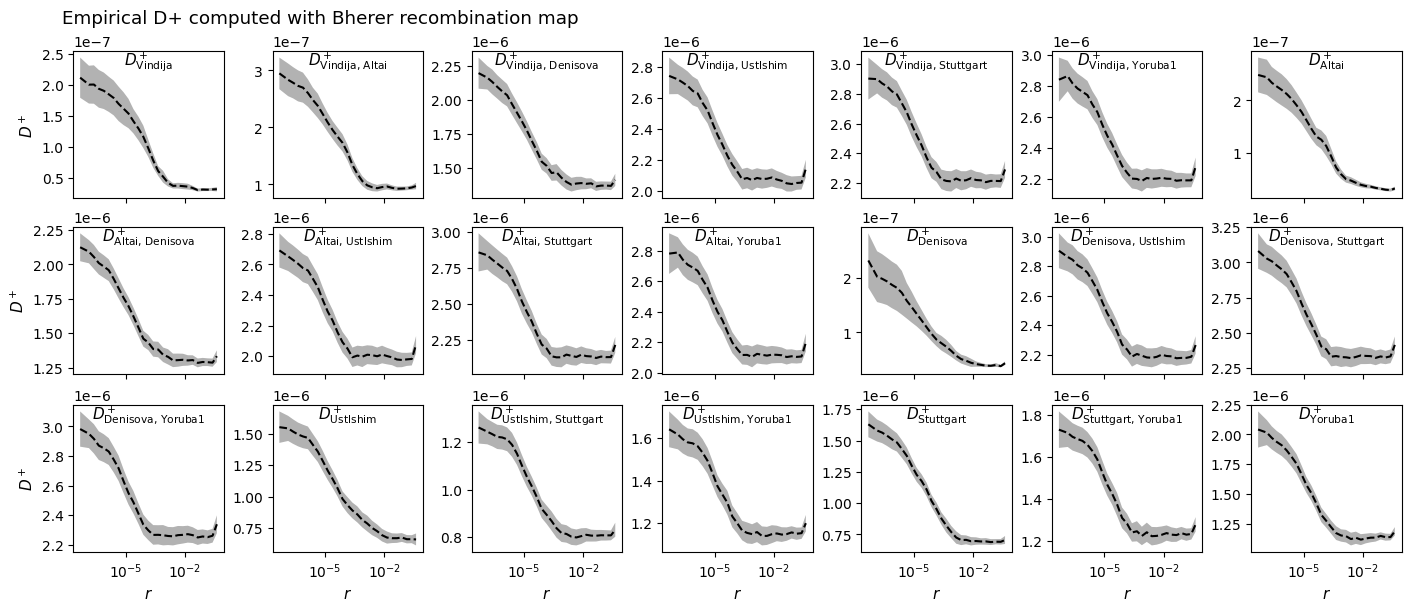

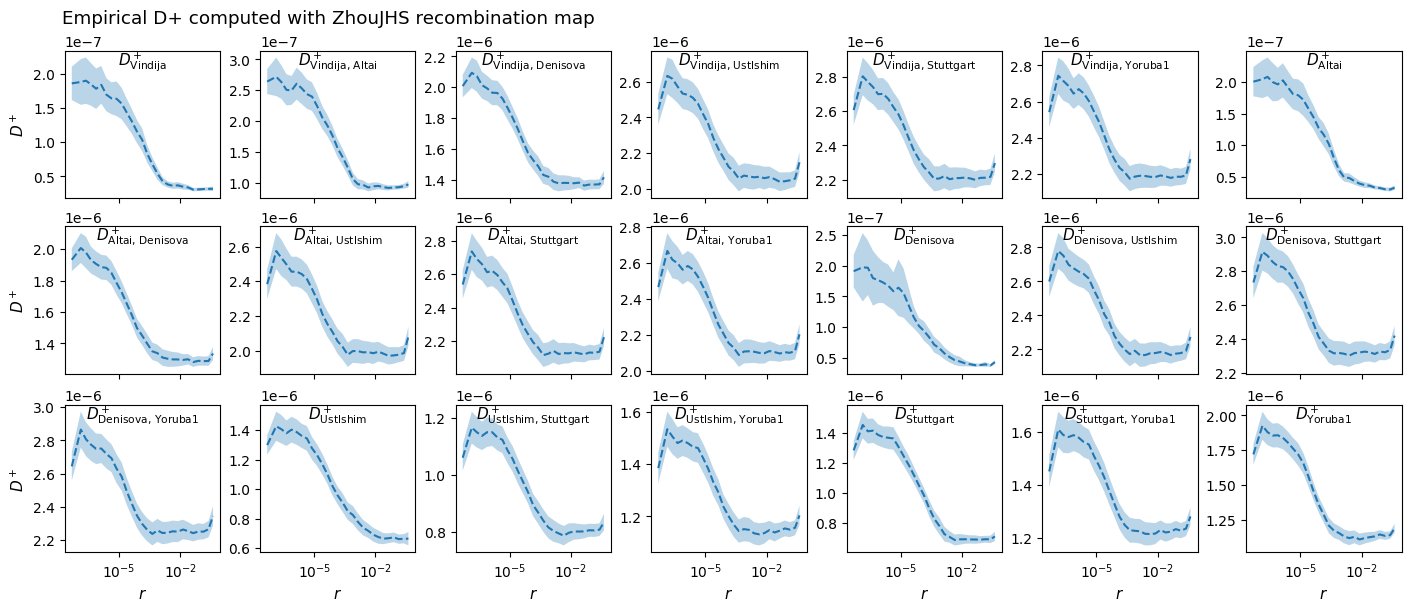

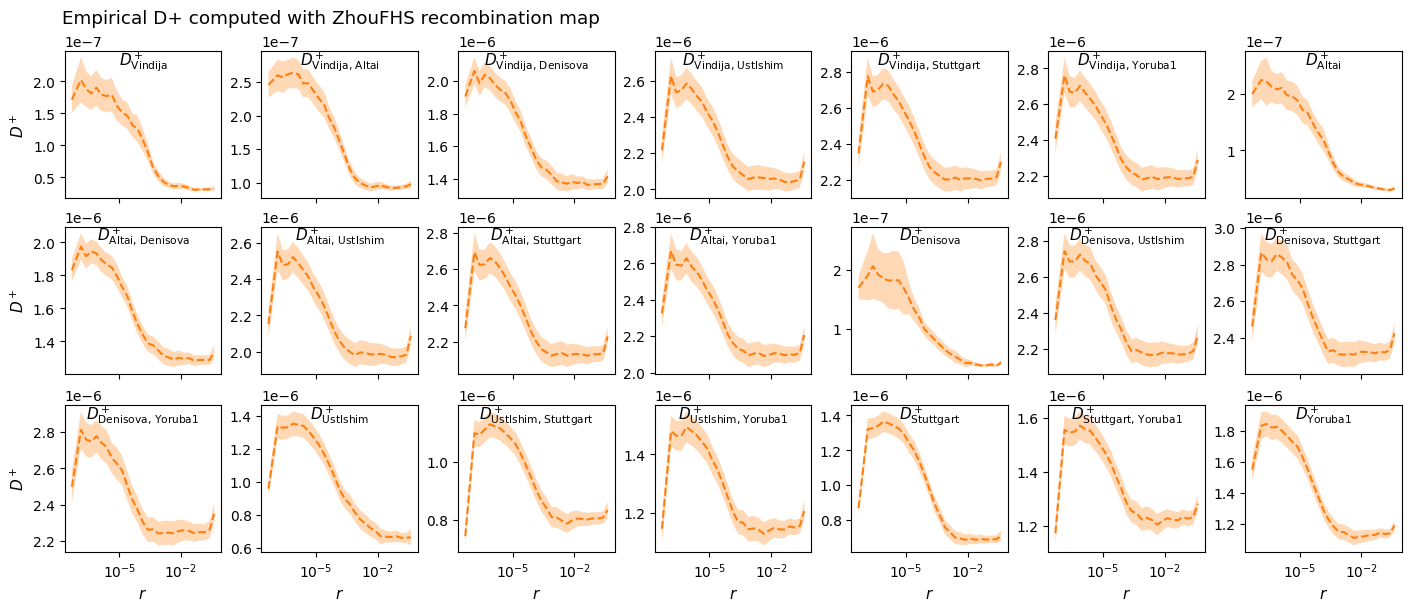

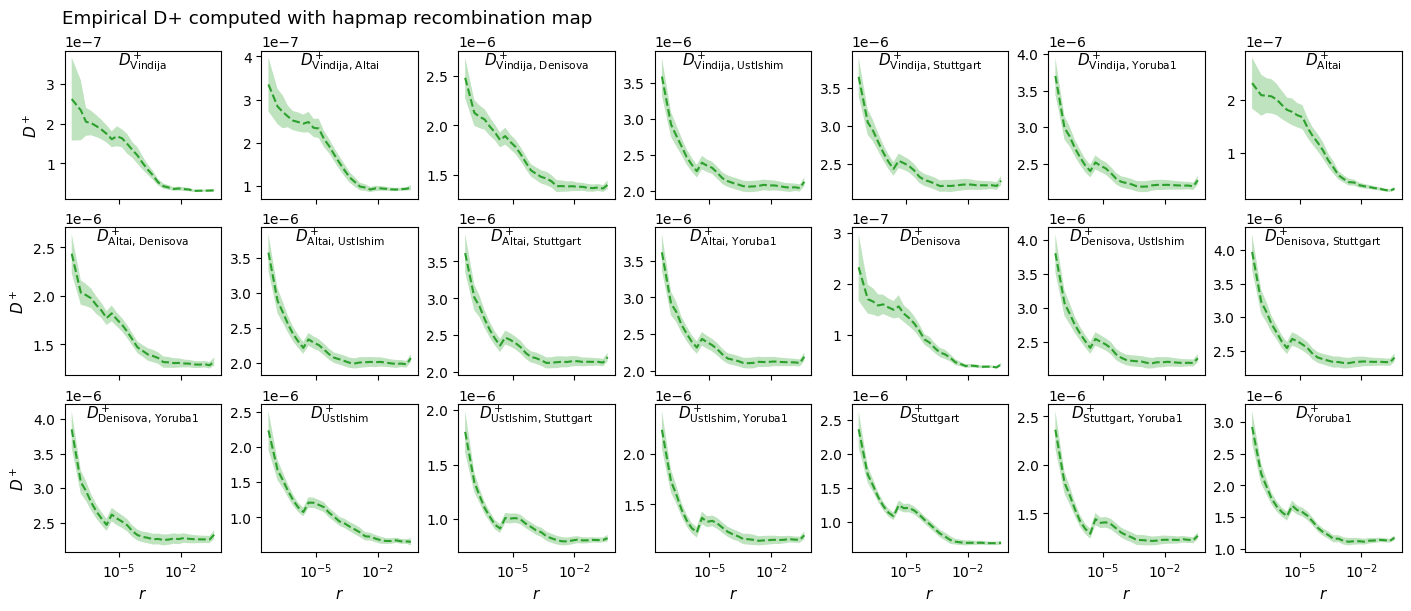

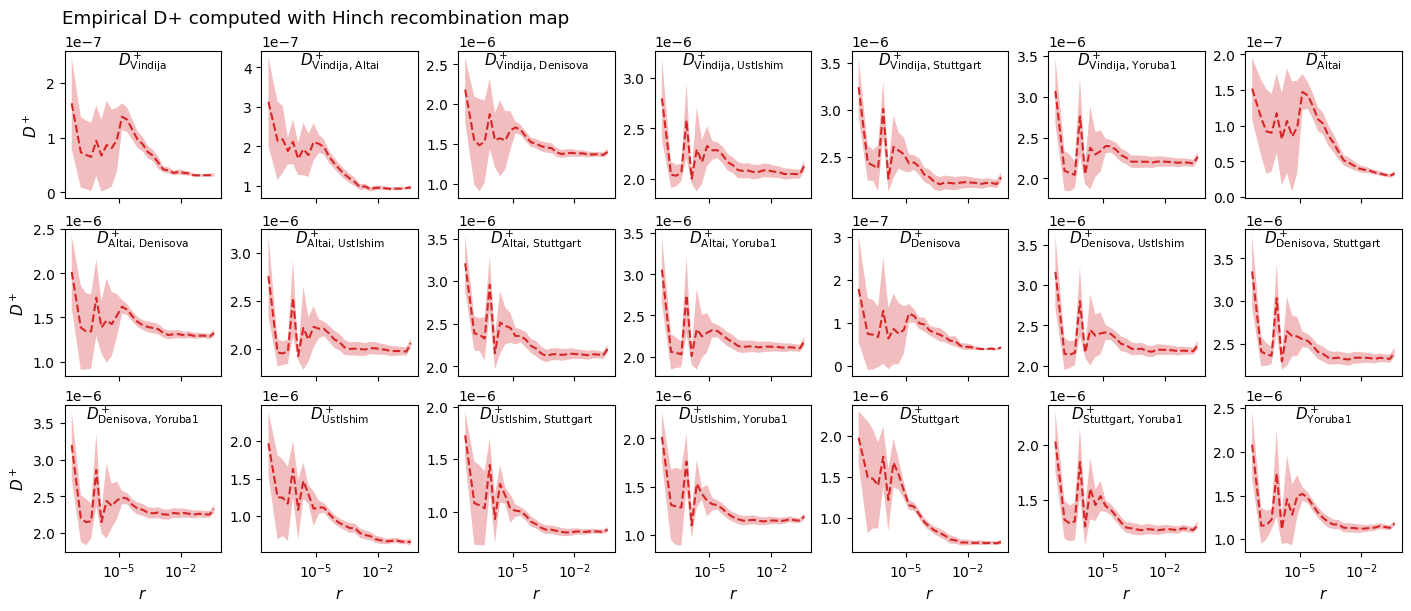

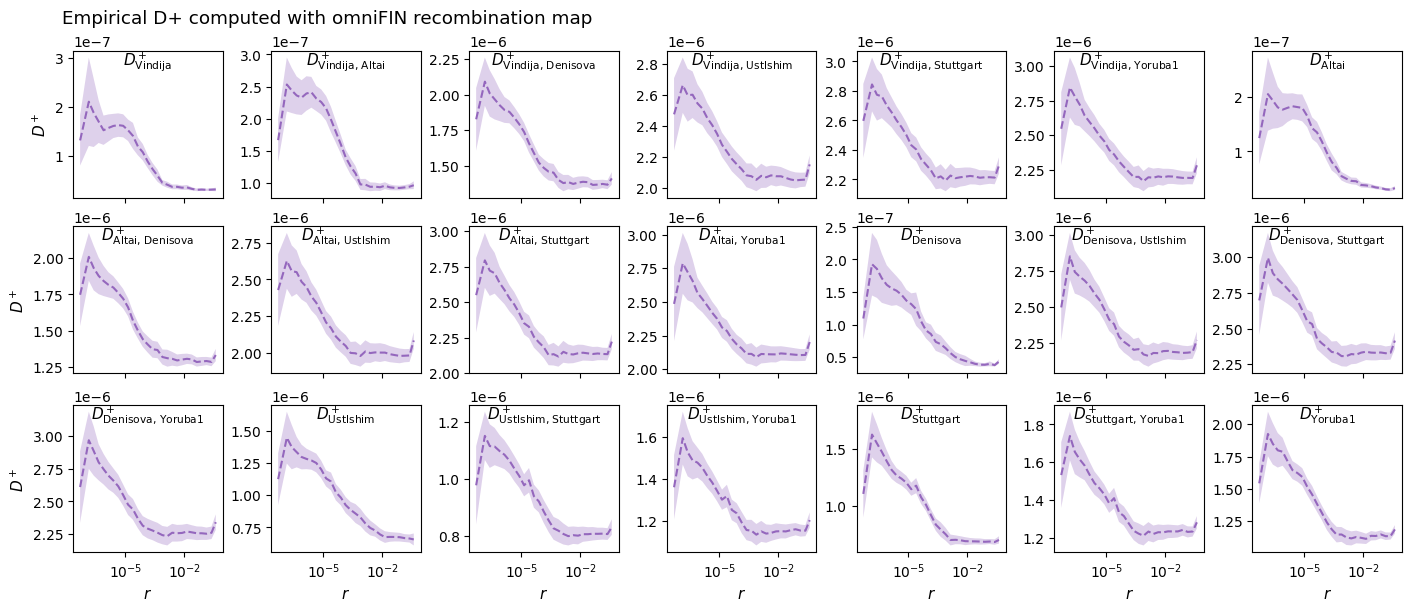

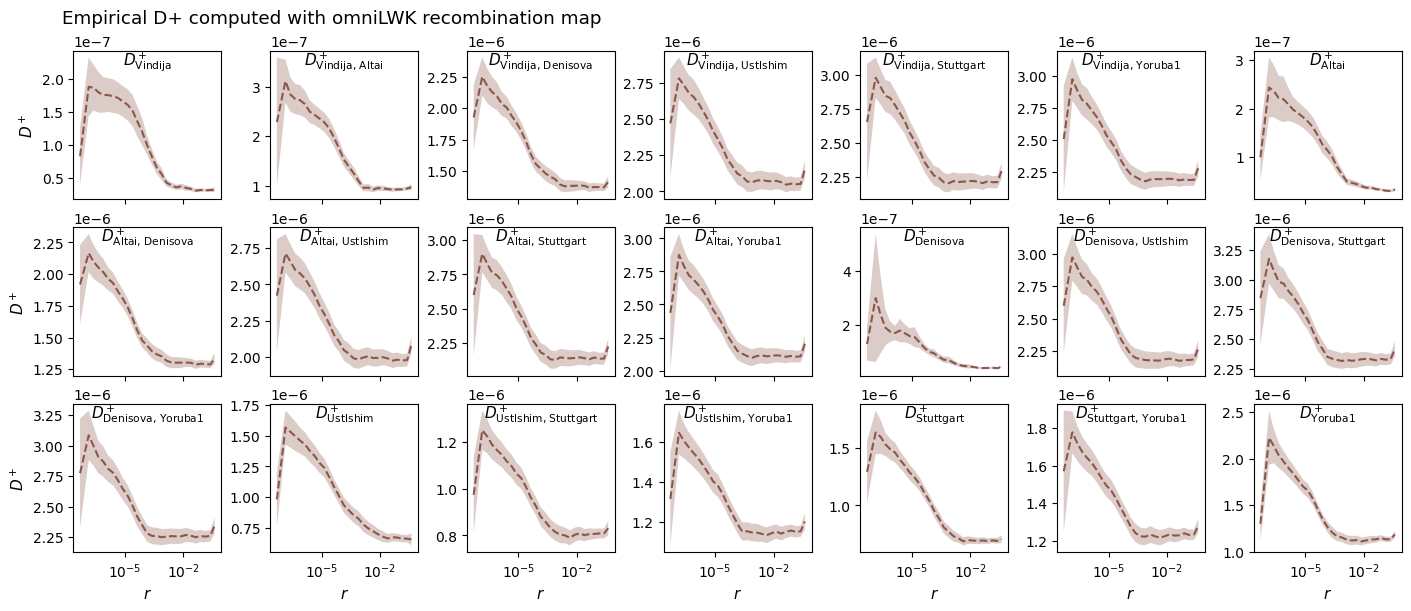

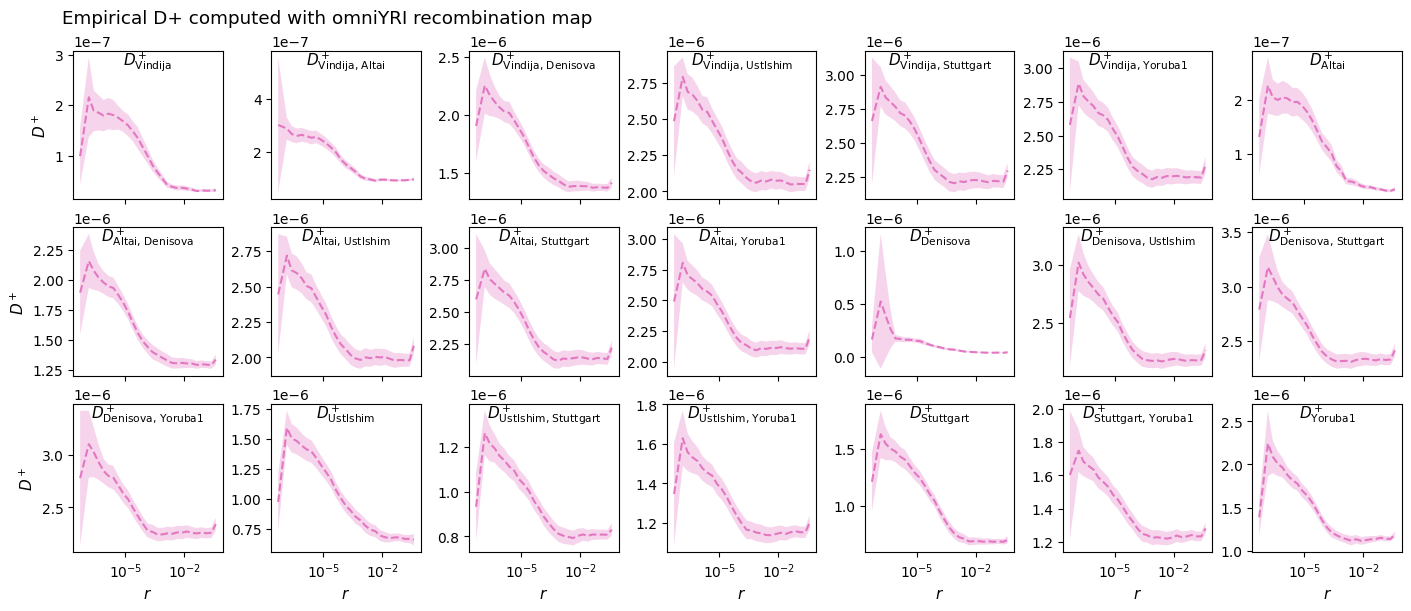

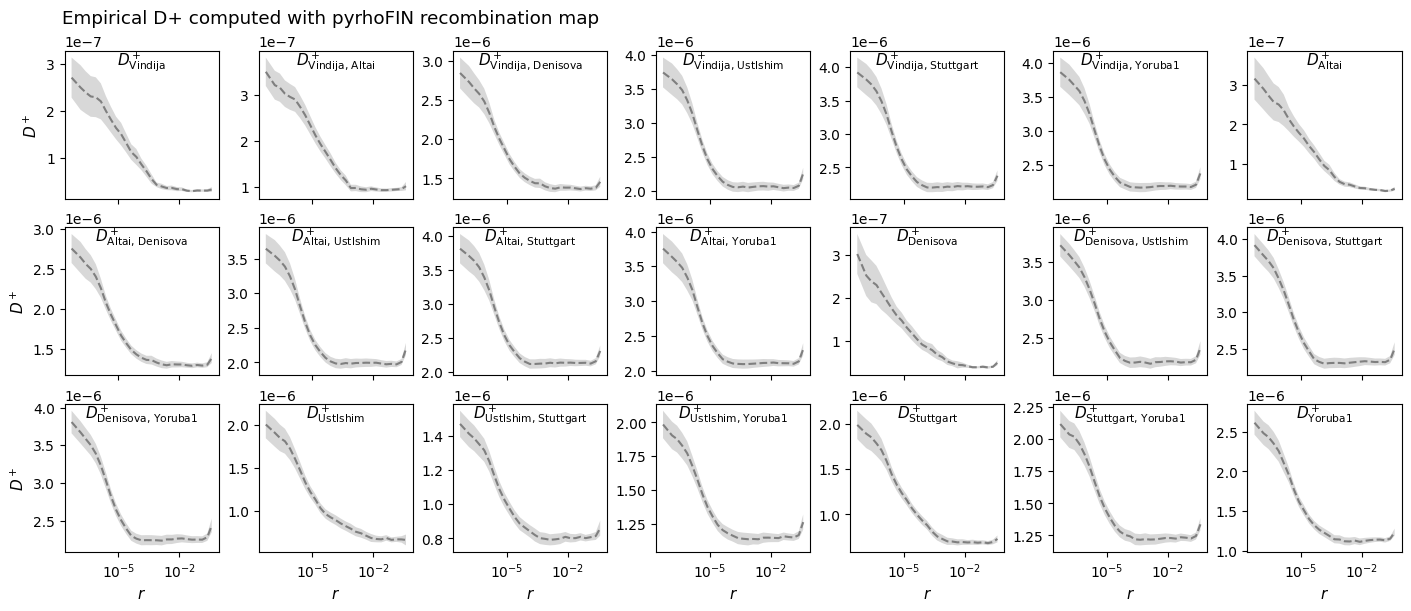

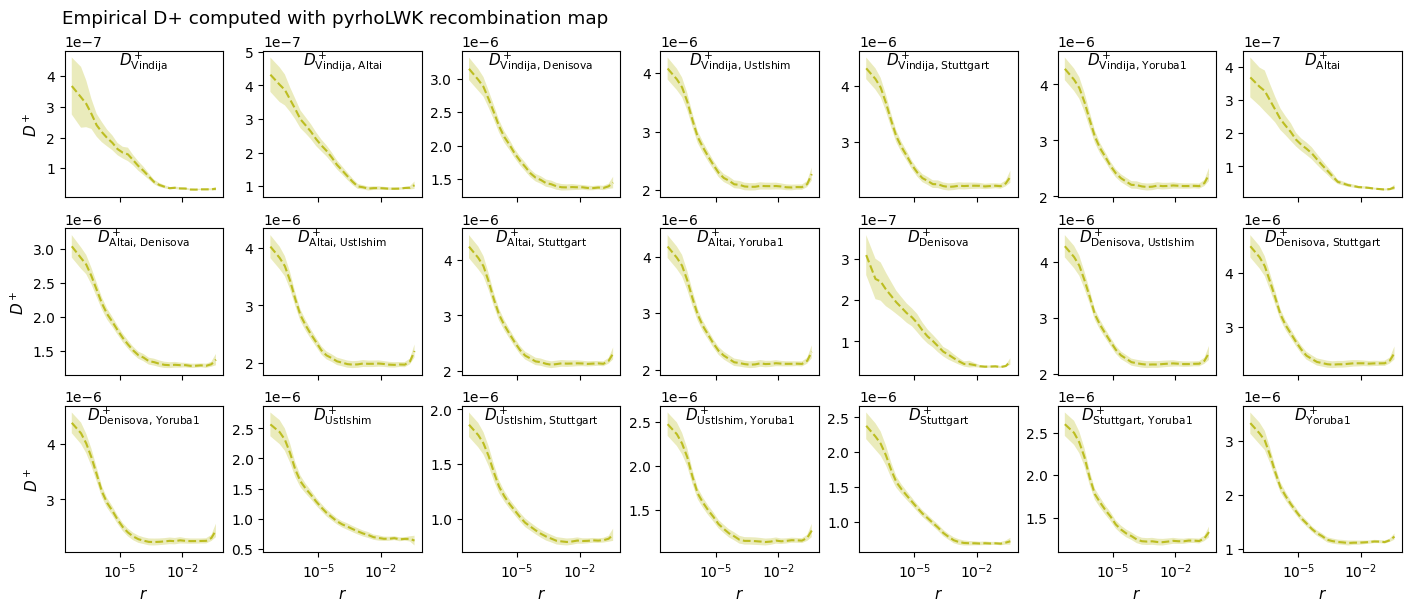

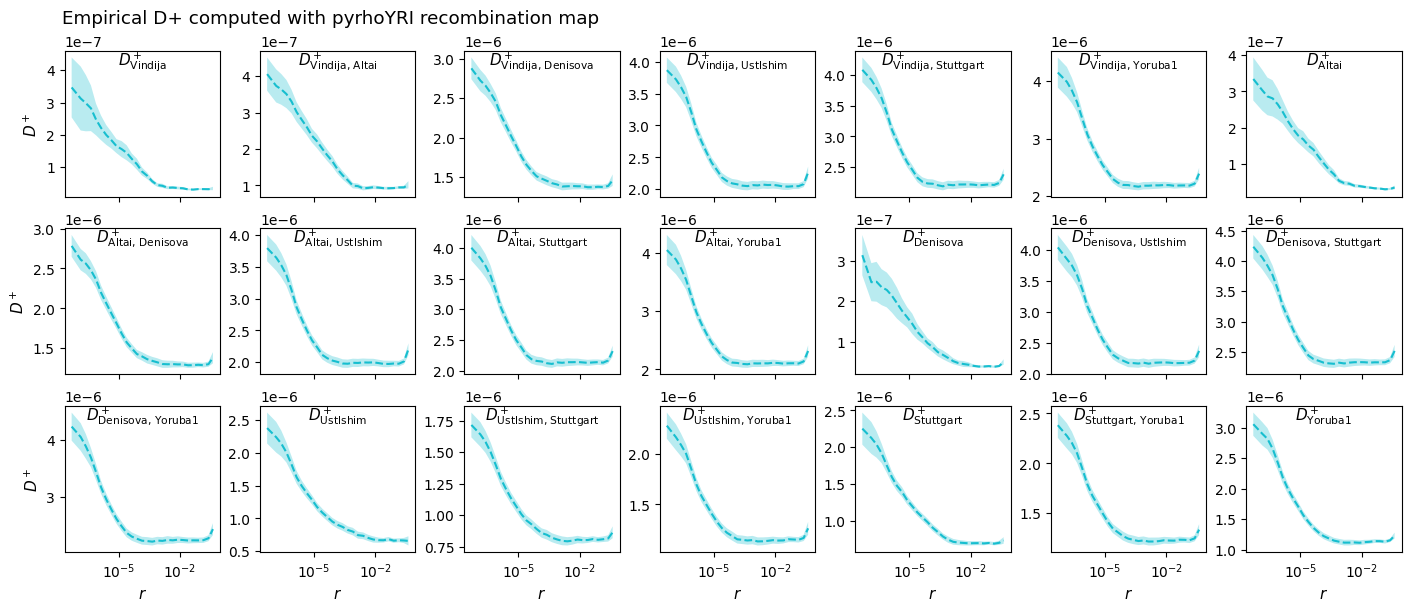

In [15]:
# Plot statistics from each map on a separate figure
for rmap in rmaps:
    dpluspy.plotting.plot_D_plus_curves(
        means=means[rmap], 
        varcovs=varcovs[rmap], 
        bins=bins,
        pop_ids=pop_ids, 
        labels=[rmap], 
        out=f"figures/fig_{rmap}_summary.pdf",
        title=f"Empirical D+ computed with {rmap} recombination map",
        show=False,
        cols=7,
        colors=[colors[rmap]]
    )

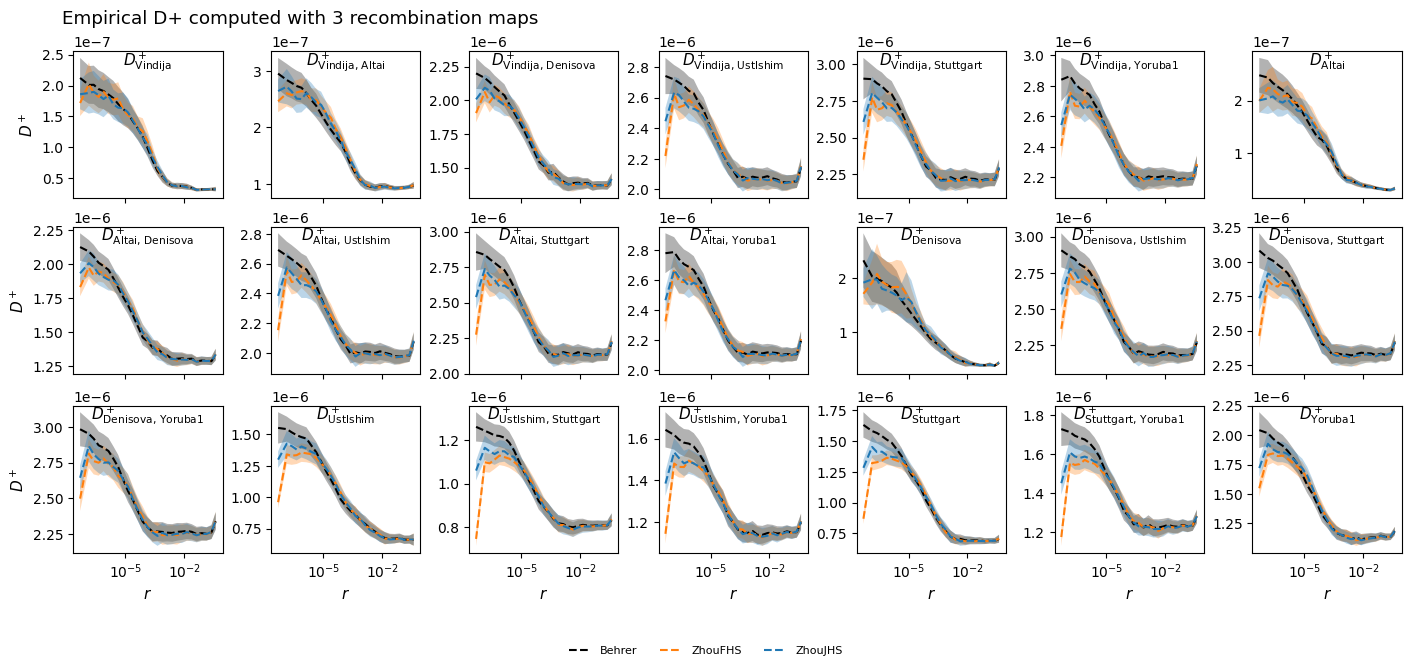

In [16]:
dpluspy.plotting.plot_D_plus_curves(
    means=[means["Bherer"], means["ZhouFHS"], means["ZhouJHS"]], 
    varcovs=[varcovs["Bherer"], varcovs["ZhouFHS"], varcovs["ZhouJHS"]], 
    bins=bins,
    pop_ids=pop_ids, 
    labels=["Behrer", "ZhouFHS", "ZhouJHS"], 
    out=f"figures/fig_Zhou_and_Bherer_maps.pdf",
    title=f"Empirical D+ computed with 3 recombination maps",
    show=False,
    cols=7,
    colors=[colors["Bherer"], colors["ZhouFHS"], colors["ZhouJHS"]]
)

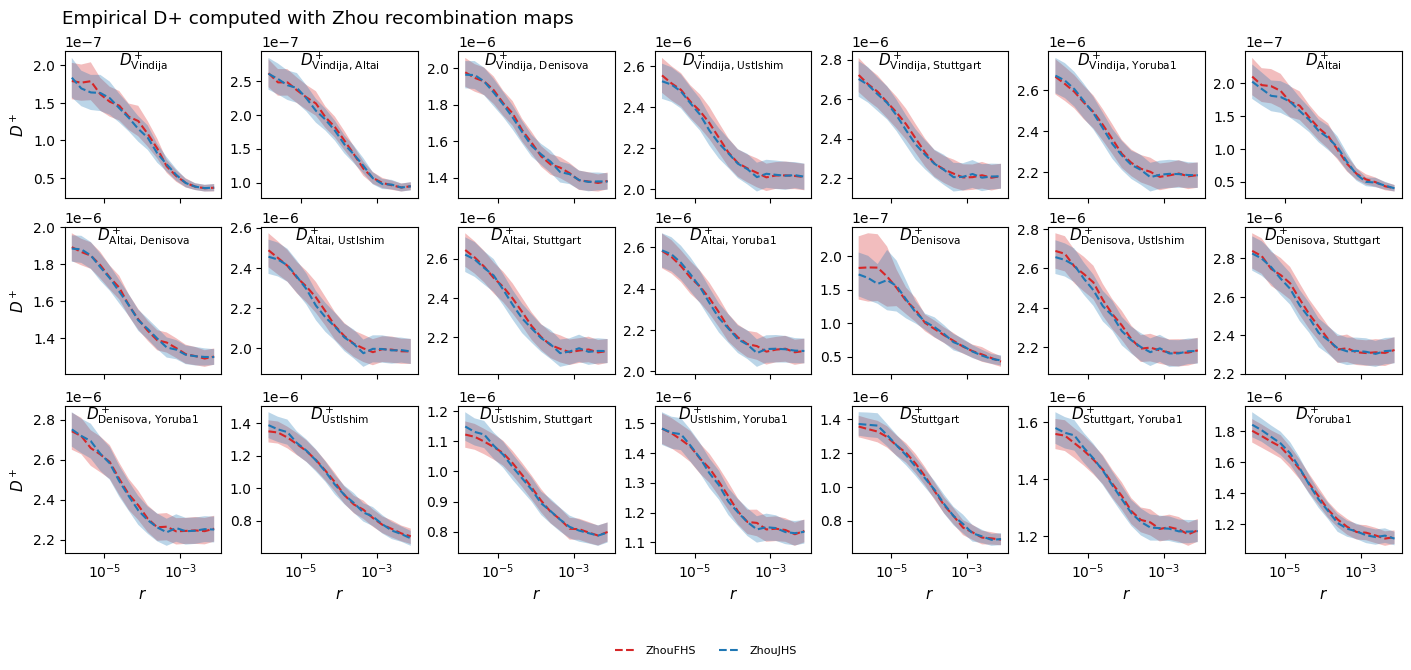

In [9]:
ZhouFHS_stats = {"pop_ids": pop_ids, "bins": bins, "means": means["ZhouFHS"],
    "varcovs": varcovs["ZhouFHS"]}
ZhouFHS_sub = dpluspy.bootstrapping.subset_stats(
    ZhouFHS_stats, min_r=1e-6, max_r=1e-2, return_dict=True)
ZhouJHS_stats = {"pop_ids": pop_ids, "bins": bins, "means": means["ZhouJHS"],
    "varcovs": varcovs["ZhouJHS"]}
ZhouJHS_sub = dpluspy.bootstrapping.subset_stats(
    ZhouJHS_stats, min_r=1e-6, max_r=1e-2, return_dict=True)

dpluspy.plotting.plot_D_plus_curves(
    means=[ZhouFHS_sub["means"], ZhouJHS_sub["means"]], 
    varcovs=[ZhouFHS_sub["varcovs"], ZhouJHS_sub["varcovs"]], 
    bins=ZhouFHS_sub["bins"],
    pop_ids=pop_ids, 
    labels=["ZhouFHS", "ZhouJHS"], 
    out=f"figures/fig_Zhou_subset_maps.pdf",
    title=f"Empirical D+ computed with Zhou recombination maps",
    show=False,
    cols=7,
    colors=["tab:red", "tab:blue"]
)